[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/obss/sahi/blob/main/demo/inference_for_ultralytics.ipynb)

## 0. Preperation

- Install latest version of SAHI and ultralytics:

In [1]:
!pip install -U torch sahi ultralytics
!pip install ipywidgets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 68.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 71.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 107.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.2/114.2 kB 11.4 MB/s eta 0:00:00


In [2]:
#import os
#os.getcwd()

- Import required modules:

In [3]:
from sahi import AutoDetectionModel
from sahi.utils.cv import read_image
from sahi.utils.file import download_from_url
from sahi.predict import get_prediction, get_sliced_prediction, predict
from IPython.display import Image

- Download two test images:

In [4]:
download_from_url('https://raw.githubusercontent.com/obss/sahi/main/demo/demo_data/small-vehicles1.jpeg', 'demo_data/small-vehicles1.jpeg')
download_from_url('https://raw.githubusercontent.com/obss/sahi/main/demo/demo_data/terrain2.png', 'demo_data/terrain2.png')
download_from_url('https://ultralytics.com/images/boats.jpg', 'demo_data/obb_test_image.png')

## 1. Standard Inference with an Ultralytics Model

- Instantiate a detection model by defining model weight path and other parameters:

In [5]:
detection_model = AutoDetectionModel.from_pretrained(
    model_type='ultralytics',
    model_path="yolo11n.pt", # any yolov8/yolov9/yolo11/yolo12/rt-detr det model is supported
    confidence_threshold=0.35,
    device="cpu", # or 'cuda:0' if GPU is available
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 5.35M/5.35M [00:00<00:00, 53.6MB/s]


- Perform prediction by feeding the get_prediction function with an image path and a DetectionModel instance:

In [6]:
result = get_prediction("demo_data/small-vehicles1.jpeg", detection_model)

- Or perform prediction by feeding the get_prediction function with a numpy image and a DetectionModel instance:

In [7]:
result = get_prediction(read_image("demo_data/small-vehicles1.jpeg"), detection_model)

- Visualize predicted bounding boxes and masks over the original image:

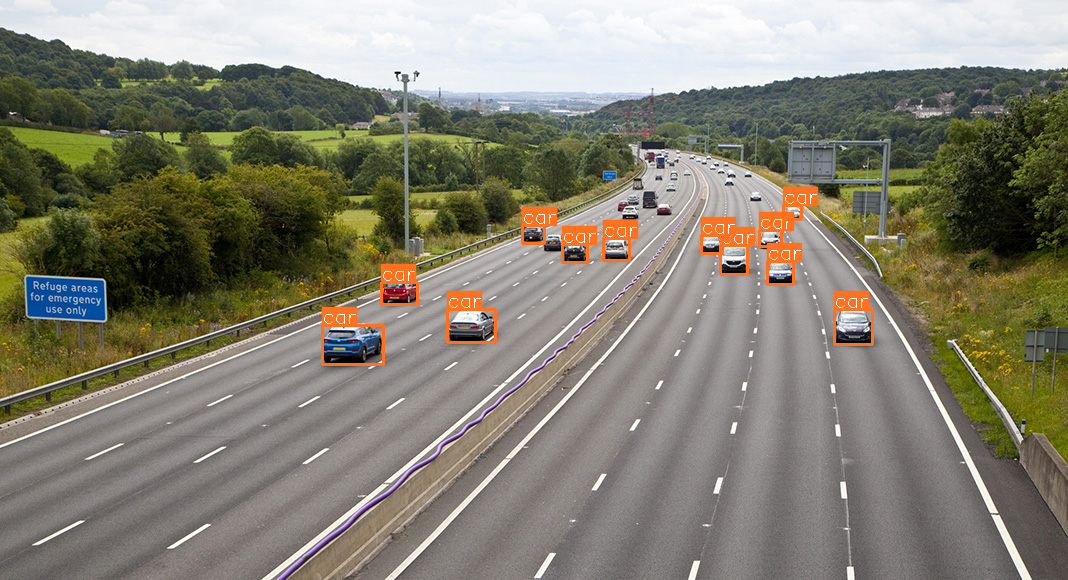

In [8]:
result.export_visuals(export_dir="demo_data/", hide_conf=True)

Image("demo_data/prediction_visual.png")

## 2. Sliced Inference with a YOLOv8/YOLO11 Model

- To perform sliced prediction we need to specify slice parameters. In this example we will perform prediction over slices of 256x256 with an overlap ratio of 0.2:

In [9]:
result = get_sliced_prediction(
    "demo_data/small-vehicles1.jpeg",
    detection_model,
    slice_height = 256,
    slice_width = 256,
    overlap_height_ratio = 0.2,
    overlap_width_ratio = 0.2
)

Performing prediction on 15 slices.


- Visualize predicted bounding boxes and masks over the original image:

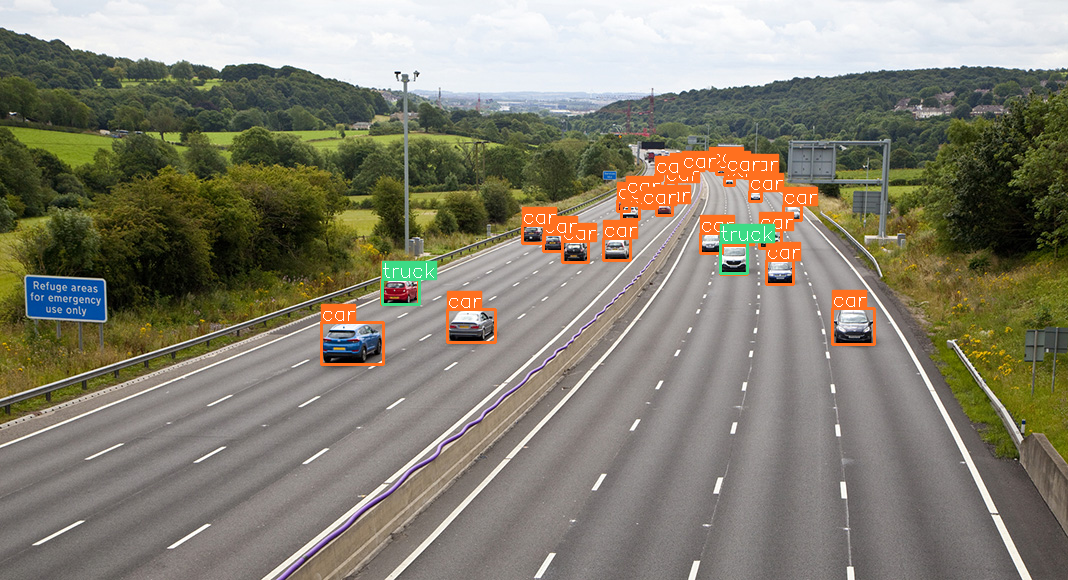

In [10]:
result.export_visuals(export_dir="demo_data/", hide_conf=True)

Image("demo_data/prediction_visual.png")

## 3. Prediction Result

- Predictions are returned as [sahi.prediction.PredictionResult](sahi/prediction.py), you can access the object prediction list as:

In [11]:
object_prediction_list = result.object_prediction_list

In [12]:
object_prediction_list[0]

ObjectPrediction<
    bbox: BoundingBox: <(np.float64(447.7865905761719), np.float64(309.0754089355469), np.float64(495.3778533935547), np.float64(342.2126770019531)), w: 47.59126281738281, h: 33.13726806640625>,
    mask: None,
    score: PredictionScore: <value: 0.9220684170722961>,
    category: Category: <id: 2, name: car>>

- ObjectPrediction's can be converted to [COCO annotation](https://cocodataset.org/#format-data) format:

In [13]:
result.to_coco_annotations()[:3]

[{'image_id': None,
  'bbox': [447.7865905761719,
   309.0754089355469,
   47.59126281738281,
   33.13726806640625],
  'score': 0.9220684170722961,
  'category_id': 2,
  'category_name': 'car',
  'segmentation': [],
  'iscrowd': 0,
  'area': 1577},
 {'image_id': None,
  'bbox': [832.6653289794922,
   308.7012710571289,
   41.41851043701172,
   36.02068328857422],
  'score': 0.8925945162773132,
  'category_id': 2,
  'category_name': 'car',
  'segmentation': [],
  'iscrowd': 0,
  'area': 1491},
 {'image_id': None,
  'bbox': [766.1782531738281,
   260.6600875854492,
   27.710235595703125,
   23.558876037597656],
  'score': 0.8331308364868164,
  'category_id': 2,
  'category_name': 'car',
  'segmentation': [],
  'iscrowd': 0,
  'area': 652}]

- ObjectPrediction's can be converted to [COCO prediction](https://github.com/i008/COCO-dataset-explorer) format:

In [14]:
result.to_coco_predictions(image_id=1)[:3]

[{'image_id': 1,
  'bbox': [447.7865905761719,
   309.0754089355469,
   47.59126281738281,
   33.13726806640625],
  'score': 0.9220684170722961,
  'category_id': 2,
  'category_name': 'car',
  'segmentation': [],
  'iscrowd': 0,
  'area': 1577},
 {'image_id': 1,
  'bbox': [832.6653289794922,
   308.7012710571289,
   41.41851043701172,
   36.02068328857422],
  'score': 0.8925945162773132,
  'category_id': 2,
  'category_name': 'car',
  'segmentation': [],
  'iscrowd': 0,
  'area': 1491},
 {'image_id': 1,
  'bbox': [766.1782531738281,
   260.6600875854492,
   27.710235595703125,
   23.558876037597656],
  'score': 0.8331308364868164,
  'category_id': 2,
  'category_name': 'car',
  'segmentation': [],
  'iscrowd': 0,
  'area': 652}]

- ObjectPrediction's can be converted to [imantics](https://github.com/jsbroks/imantics) annotation format:

In [15]:
!pip install imantics
result.to_imantics_annotations()[:3]

  Preparing metadata (setup.py) ... done
  Created wheel for imantics: filename=imantics-0.1.12-py3-none-any.whl size=16009 sha256=d9f9ea969e020110f4cf6faeec0bcb03bbc924d0c4ded2282c3c9d2b2b36ebd8
  Stored in directory: /root/.cache/pip/wheels/8c/7e/91/8fba0377906bcb6bf32ce48286924f37bb453a1761ffcf44e1
Successfully built imantics


- ObjectPrediction's can be converted to [fiftyone](https://github.com/voxel51/fiftyone) detection format:

In [16]:
!pip install fiftyone
result.to_fiftyone_detections()[:3]

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 108.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.9/110.9 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.4/112.4 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 80.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 943.0/943.0 kB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.6/139.6 kB 13.4 MB/s eta 0

[<Detection: {
     'id': '67f4f100b0005e64b5fbd915',
     'attributes': {},
     'tags': [],
     'label': 'car',
     'bounding_box': [
         0.4192758338728201,
         0.5328886360957705,
         0.044561107506912744,
         0.057133220804148704,
     ],
     'mask': None,
     'mask_path': None,
     'confidence': 0.9220684170722961,
     'index': None,
 }>,
 <Detection: {
     'id': '67f4f100b0005e64b5fbd916',
     'attributes': {},
     'tags': [],
     'label': 'car',
     'bounding_box': [
         0.7796491844377268,
         0.5322435707881533,
         0.038781376813681386,
         0.06210462635961072,
     ],
     'mask': None,
     'mask_path': None,
     'confidence': 0.8925945162773132,
     'index': None,
 }>,
 <Detection: {
     'id': '67f4f100b0005e64b5fbd917',
     'attributes': {},
     'tags': [],
     'label': 'car',
     'bounding_box': [
         0.7173953681402885,
         0.44941394411284347,
         0.025945913479122777,
         0.0406187517889614

## 4. Batch Prediction

- Set model and directory parameters:

In [17]:
model_type = "ultralytics"
model_path = 'yolo11n.pt'
model_device = "cpu" # or 'cuda:0' if GPU is available
model_confidence_threshold = 0.4

slice_height = 256
slice_width = 256
overlap_height_ratio = 0.2
overlap_width_ratio = 0.2

source_image_dir = "demo_data/"

- Perform sliced inference on given folder:

In [18]:
predict(
    model_type=model_type,
    model_path=model_path,
    model_device=model_device,
    model_confidence_threshold=model_confidence_threshold,
    source=source_image_dir,
    slice_height=slice_height,
    slice_width=slice_width,
    overlap_height_ratio=overlap_height_ratio,
    overlap_width_ratio=overlap_width_ratio,
)

There are 4 listed files in folder: demo_data/


Performing inference on images:   0%|          | 0/4 [00:00<?, ?it/s]

Performing prediction on 15 slices.


Performing inference on images:  25%|██▌       | 1/4 [00:04<00:13,  4.34s/it]

Prediction time is: 4276.92 ms
Performing prediction on 15 slices.


...

Prediction time is: 3756.08 ms
Performing prediction on 20 slices.


Performing inference on images:  75%|███████▌  | 3/4 [00:11<00:03,  3.62s/it]

Prediction time is: 3098.25 ms
Performing prediction on 60 slices.


Performing inference on images: 100%|██████████| 4/4 [00:20<00:00,  5.14s/it]

Prediction time is: 9177.81 ms
Prediction results are successfully exported to runs/predict/exp


# 5 Sliced Segmentation

Run the same steps for YOLO11 segmentation model:

In [19]:
detection_model_seg = AutoDetectionModel.from_pretrained(
    model_type='ultralytics',
    model_path='yolo11n-seg.pt', # any yolov8/yolov9/yolo11/yolo12 seg model is supported
    confidence_threshold=0.3,
    device="cpu", # or 'cuda:0' if GPU is available
)

im = read_image("demo_data/small-vehicles1.jpeg")

100%|██████████| 5.90M/5.90M [00:00<00:00, 69.2MB/s]


- Perform standard segmentation:

In [20]:
result = get_prediction(im, detection_model_seg)

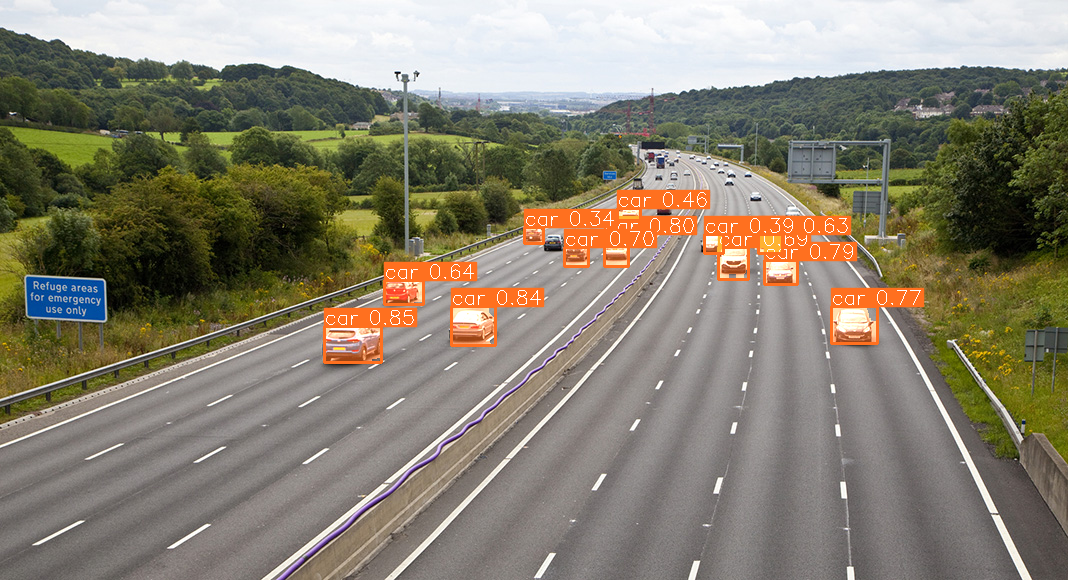

In [21]:
result.export_visuals(export_dir="demo_data/")

Image("demo_data/prediction_visual.png")

- Repeat for sliced segmentation:

In [22]:
result = get_sliced_prediction(
    im,
    detection_model_seg,
    slice_height = 256,
    slice_width = 256,
    overlap_height_ratio = 0.2,
    overlap_width_ratio = 0.2
)

Performing prediction on 15 slices.


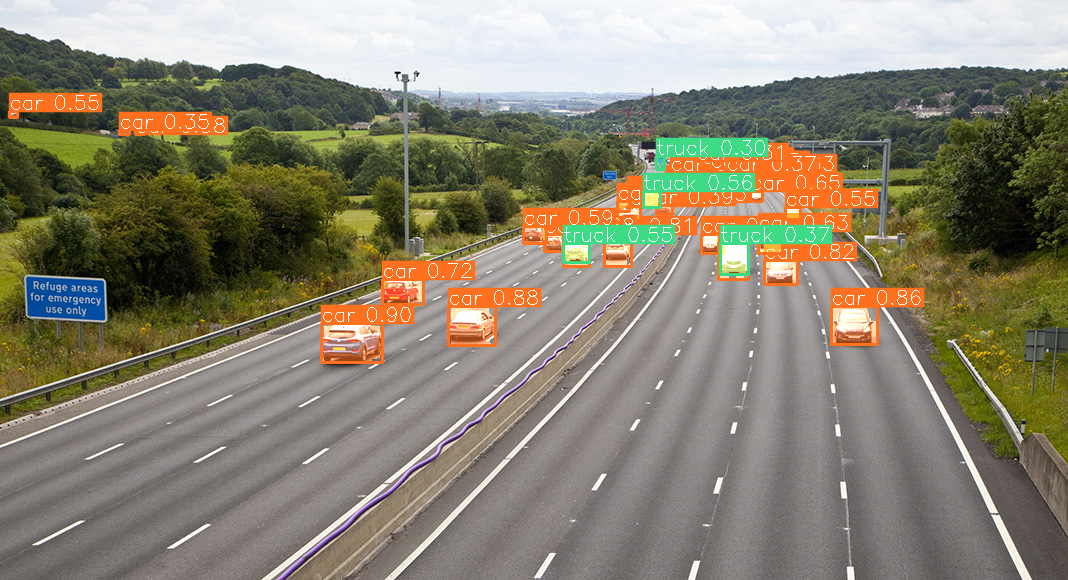

In [23]:
result.export_visuals(export_dir="demo_data/")

Image("demo_data/prediction_visual.png")

Sliced predictions are much better!

- Observe the prediction format:

In [24]:
object_prediction_list = result.object_prediction_list
object_prediction_list[0]

ObjectPrediction<
    bbox: BoundingBox: <(321, 323, 382, 362), w: 61, h: 39>,
    mask: <sahi.annotation.Mask object at 0x7d939b9d6b10>,
    score: PredictionScore: <value: 0.9011313319206238>,
    category: Category: <id: 2, name: car>>

In [25]:
object_prediction_list[0].mask.segmentation

[[322,
  338,
  321,
  338,
  321,
  356,
  321,
  357,
  322,
  357,
  323,
  358,
  323,
  359,
  323,
  360,
  324,
  361,
  325,
  362,
  326,
  362,
  328,
  362,
  342,
  362,
  344,
  360,
  356,
  360,
  358,
  362,
  365,
  362,
  367,
  360,
  371,
  360,
  371,
  359,
  372,
  358,
  376,
  358,
  377,
  357,
  379,
  357,
  379,
  355,
  381,
  353,
  381,
  351,
  382,
  351,
  382,
  336,
  381,
  335,
  380,
  334,
  380,
  333,
  379,
  332,
  379,
  326,
  371,
  326,
  370,
  325,
  369,
  325,
  368,
  324,
  368,
  323,
  335,
  323,
  335,
  324,
  334,
  325,
  333,
  325,
  332,
  325,
  332,
  326,
  324,
  326,
  324,
  336]]

In [26]:
predict(
    model_type=model_type,
    model_path=model_path,
    model_device=model_device,
    model_confidence_threshold=model_confidence_threshold,
    source=source_image_dir,
    slice_height=slice_height,
    slice_width=slice_width,
    overlap_height_ratio=overlap_height_ratio,
    overlap_width_ratio=overlap_width_ratio,
)

There are 4 listed files in folder: demo_data/


Performing inference on images:   0%|          | 0/4 [00:00<?, ?it/s]

Performing prediction on 15 slices.


Performing inference on images:  25%|██▌       | 1/4 [00:02<00:06,  2.21s/it]

Prediction time is: 2170.46 ms
Performing prediction on 15 slices.


...

Prediction time is: 2066.45 ms
Performing prediction on 20 slices.


Performing inference on images:  75%|███████▌  | 3/4 [00:07<00:02,  2.45s/it]

Prediction time is: 2755.93 ms
Performing prediction on 60 slices.


Performing inference on images: 100%|██████████| 4/4 [00:15<00:00,  3.92s/it]

Prediction time is: 8464.02 ms
Prediction results are successfully exported to runs/predict/exp2


# 7 Sliced OBB Prediction


In [27]:
detection_model_obb = AutoDetectionModel.from_pretrained(
    model_type='ultralytics',
    model_path='yolo11n-obb.pt', # any yolov8/yolov9/yolo11/yolo12 obb model is supported
    confidence_threshold=0.3,
    device="cuda:0", # or 'cuda:0' if GPU is available
)

im = read_image("demo_data/obb_test_image.png")


100%|██████████| 5.53M/5.53M [00:00<00:00, 63.2MB/s]


In [28]:
result = get_sliced_prediction(
    im,
    detection_model_obb,
    slice_height = 512,
    slice_width = 512,
    overlap_height_ratio = 0.2,
    overlap_width_ratio = 0.2,
    #perform_standard_pred = False
)

Performing prediction on 15 slices.


In [29]:
result.export_visuals(export_dir="demo_data/", text_size=1, rect_th=3, hide_conf=True)

Image("demo_data/prediction_visual.png", width=800)

Output hidden; open in https://colab.research.google.com to view.